In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import f1_score 

In [196]:
dior = pd.read_csv("dior_clean.csv")
dior.corr(numeric_only=True)["is_return"].sort_values(ascending=False) 
#If there is an irealistic correlation, it would indicate some dataleakage (That is why I got rid off timespan_days_less_than_10)

is_return                                 1.000000
product_subcategory_Apparel (Clothing)    0.101060
quantity_0.0                              0.089422
product_subcategory_Footwear              0.082679
sales_band_2000_4000                      0.054289
                                            ...   
product_subcategory_Home & Lifestyle     -0.074212
csc commercial gestures                  -0.093344
sales_band_0_500                         -0.110355
is_ltsourcing                            -0.184140
timespan_days_less_than_10               -0.983972
Name: is_return, Length: 112, dtype: float64

In [197]:
#We prepare the data, split it into train and test and prepare the cross validation
X, y = dior.drop(columns=["order number", "order status", "is_return", "timespan_days_less_than_10"]), dior["is_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)
cv = KFold(n_splits=3, shuffle=True, random_state=72)

In [198]:
#Let us see the repartition of the two classes
display(  round( y_train.value_counts()/y_train.shape[0], 3   ))

is_return
0    0.683
1    0.317
Name: count, dtype: float64

In [199]:
#Test 1: Use Naive Bayes
nbc = GaussianNB()

nbc.fit(X_train, y_train)

y_pred_train_bayes = nbc.predict(X_train)
y_pred_test_bayes = nbc.predict(X_test)
p_nbc_test = nbc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.3f}")
print(f"Accuracy train Bayes: {accuracy_score(y_train, y_pred_train_bayes):.3f}")
print(f"F1-score test Bayes: {f1_score(y_test, y_pred_test_bayes):.3f}")
print(f"F1-score train Bayes: {f1_score(y_train, y_pred_train_bayes):.3f}")
#The results seem to be very bad. This can be explained that 
# Explanation: Naive Bayes performs poorly here because many features (like the US states) are highly correlated, which breaks the model's independence assumption.

Accuracy test Bayes: 0.423
Accuracy train Bayes: 0.420
F1-score test Bayes: 0.524
F1-score train Bayes: 0.520


In [200]:
p_nbc_train = nbc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
best_t_Bayes_acc = 0.5
best_acc = 0

for t in thresholds:
    preds = (p_nbc_train >= t).astype(int)
    Accuracy = accuracy_score(y_train, preds)
    if Accuracy > best_acc:
        best_acc = Accuracy
        best_t_Bayes_acc = t

print(f"Best threshold {best_t_Bayes_acc:.3f}")
print(f"Best Accuracy {best_acc:.3f}")

y_pred_test_bayes_tunedacc = (p_nbc_test >= best_t)

print(f"Accuracy test Bayes with tuned threshold: {accuracy_score(y_test, y_pred_test_bayes_tunedacc):.3f}")

Best threshold 0.980
Best Accuracy 0.420
Accuracy test Bayes with tuned threshold: 0.423


In [201]:
p_train = nbc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
best_t_Bayes_f1 = 0.5
best_f1 = 0

for t in thresholds:
    preds = (p_train >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t_Bayes_f1 = t

print(f"Best threshold {best_t_Bayes_f1:.3f}")
print(f"Best F1 {best_f1:.3f}")

y_pred_test_bayes_tunedf1 = (p_nbc_test >= best_t_Bayes_f1)

print(f"F1-score test Bayes with tuned threshold {f1_score(y_test, y_pred_test_bayes_tunedf1):.3f}")

Best threshold 0.220
Best F1 0.520
F1-score test Bayes with tuned threshold 0.525


In [202]:
#Test 2: Use Classifier which always predicts the most common class

# What is the most common class?
display(  round( y_train.value_counts()/y_train.shape[0], 3   ))

# So we predict always zero for the "most-common" classifier
y_pred_train_mc = np.zeros(len(y_train))
y_pred_test_mc = np.zeros(len(y_test))


print(f"Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.3f}")
print(f"Accuracy train Most Common: {accuracy_score(y_train, y_pred_train_mc):.3f}")
print(f"F1-score test Most Common: {f1_score(y_test, y_pred_test_mc):.3f}")
print(f"F1-score train Most Common: {f1_score(y_train, y_pred_train_mc):.3f}")
#It points out how bad the accuracy of our naïve Bayes classifier ist
#The high accuracy can also be explained by the disproportion between the two classes
#The f1-score is equal to 0 as there are no True Positives predicted

is_return
0    0.683
1    0.317
Name: count, dtype: float64

Accuracy test Most Common: 0.680
Accuracy train Most Common: 0.683
F1-score test Most Common: 0.000
F1-score train Most Common: 0.000


In [203]:
#Test 3: Use Logistic Regression
lrc = LogisticRegression(max_iter=5000, penalty = None)

lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg: {accuracy_score(y_test, y_pred_test_lrc):.3f}")
print(f"Accuracy train Logreg: {accuracy_score(y_train, y_pred_train_lrc):.3f}")
print(f"F1-score test Logreg: {f1_score(y_test, y_pred_test_lrc):.3f}")
print(f"F1-score train Logreg: {f1_score(y_train, y_pred_train_lrc):.3f}")


# It manages to converge with a not too bad accuracy performance

# Here the model tries to minimize the log-loss function using gradient descent; 
# that is why we have to decide how many iterations we want

Accuracy test Logreg: 0.697
Accuracy train Logreg: 0.702
F1-score test Logreg: 0.238
F1-score train Logreg: 0.240


In [204]:
# Let us see if it is necessary to adapt the threshold as there are clearly more products that are not returned then products that are returned
dior["is_return"].value_counts()

p_train = lrc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_acc = 0.5
best_accuracy = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    accuracy = accuracy_score(y_train, y_pred_train_thresh)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold_lrc_acc = t

print(f"Best accuracy: {best_accuracy:.3f}")
print(f"Best Threshold: {best_threshold_lrc_acc:.3f}")

# There seems to have no sense adapting the threshold to have better accuracy

p_test = lrc.predict_proba(X_test)[:, 1]
y_pred_lrcacc_test_best_thresh = (p_test >= best_threshold_lrc_acc).astype(int)
print(f"Accuracy test Logreg with tuned threshold {accuracy_score(y_test, y_pred_lrcacc_test_best_thresh):.3f}")

Best accuracy: 0.702
Best Threshold: 0.500
Accuracy test Logreg with tuned threshold 0.697


In [205]:
#What would be the results if we want to maximize the f1-score
dior["is_return"].value_counts()

p_train = lrc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_f1:.3f}")

p_test = lrc.predict_proba(X_test)[:, 1]
y_pred_lrcf1_test_best_thresh = (p_test >= best_threshold_lrc_f1).astype(int)
print(f"F1-score test Logreg with tuned threshold {f1_score(y_test, y_pred_lrcf1_test_best_thresh):.3f}")



Best f1: 0.540
Best Threshold: 0.290
F1-score test Logreg with tuned threshold 0.540


In [206]:
#Test 4: Use Logistic Regression with Lasso penalization as we could notice some overfitting in the logistic regression
lrc_lasso = LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=72)

lrc_lasso.fit(X_train, y_train)

y_pred_train_lrc_lasso = lrc_lasso.predict(X_train)
y_pred_test_lrc_lasso = lrc_lasso.predict(X_test)
p_lrc_lasso_test = lrc_lasso.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (lasso): {accuracy_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Accuracy train Logreg (lasso): {accuracy_score(y_train, y_pred_train_lrc_lasso):.3f}")
print(f"F1-score test Logreg (lasso): {f1_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"F1-score train Logreg (lasso): {f1_score(y_train, y_pred_train_lrc_lasso):.3f}")
#It does not make a huge difference but the model still performs better in the test set

# We have to change the solver into Liblinear because the estimator LogisticRegression uses per default the "lbfgs" solver
# This solver works only if we assume that the function is perfectly differenciable
# As it is not the case because of the lasso penalty we add (absolute value)
#We have to change the solver into liblinear (as this solver works with hazard; we fix a random state)

Accuracy test Logreg (lasso): 0.697
Accuracy train Logreg (lasso): 0.702
F1-score test Logreg (lasso): 0.238
F1-score train Logreg (lasso): 0.240


In [207]:
# Let us see if it is necessary to adapt the threshold as there are clearly more products that are not returned then products that are returned

p_train = lrc_lasso.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_lasso_acc = 0.5
best_accuracy = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    accuracy = accuracy_score(y_train, y_pred_train_thresh)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold_lrc_lasso_acc = t

print(f"Best accuracy: {best_accuracy:.3f}")
print(f"Best Threshold: {best_threshold_lrc_lasso_acc:.3f}")
# There seems to have no sense adapting the threshold to have better accuracy

p_test = lrc_lasso.predict_proba(X_test)[:, 1]
y_pred_lrcacc_lasso_test_best_thresh = (p_test >= best_threshold_lrc_lasso_acc).astype(int)
print(f"F1-score test Logreg (lasso) with tuned threshold {accuracy_score(y_test, y_pred_lrcacc_lasso_test_best_thresh):.3f}")


Best accuracy: 0.702
Best Threshold: 0.490
F1-score test Logreg (lasso) with tuned threshold 0.696


In [208]:
#What would be the results if we want to maximize the f1-score
dior["is_return"].value_counts()

p_train = lrc_lasso.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_lasso_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_lasso_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_lasso_f1:.3f}")

p_test = lrc_lasso.predict_proba(X_test)[:, 1]
y_pred_lrcf1_lasso_test_best_thresh = (p_test >= best_threshold_lrc_lasso_f1).astype(int)
print(f"F1-score test Logreg (lasso) with tuned threshold {f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh):.3f}")

Best f1: 0.540
Best Threshold: 0.280
F1-score test Logreg (lasso) with tuned threshold 0.542


In [209]:
#Test 5: Use Logistic Regression with Ridge penalization to see if it works better than Lasso
lrc_ridge = LogisticRegression(penalty="l2", max_iter=5000)

lrc_ridge.fit(X_train, y_train)

y_pred_train_lrc_ridge = lrc_ridge.predict(X_train)
y_pred_test_lrc_ridge = lrc_ridge.predict(X_test)
p_lrc_ridge_test = lrc_ridge.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (ridge): {accuracy_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Accuracy train Logreg (ridge): {accuracy_score(y_train, y_pred_train_lrc_ridge):.3f}")
print(f"F1-score test Logreg (ridge): {f1_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"F1-score test Logreg (ridge): {f1_score(y_train, y_pred_train_lrc_ridge):.3f}")
# That is not the case; Lasso regularization gives the best accuracy

Accuracy test Logreg (ridge): 0.696
Accuracy train Logreg (ridge): 0.702
F1-score test Logreg (ridge): 0.238
F1-score test Logreg (ridge): 0.240


In [210]:
# Let us see if it is necessary to adapt the threshold as there are clearly more products that are not returned then products that are returned
dior["is_return"].value_counts()

p_train = lrc_ridge.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_ridge_acc = 0.5
best_accuracy = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    accuracy = accuracy_score(y_train, y_pred_train_thresh)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold_lrc_ridge_acc = t

print(f"Best accuracy: {best_accuracy:.3f}")
print(f"Best Threshold: {best_threshold_lrc_ridge_acc:.3f}")
# There seems to have no sense adapting the threshold to have better accuracy

p_test = lrc_ridge.predict_proba(X_test)[:, 1]
y_pred_lrcacc_ridge_test_best_thresh = (p_test >= best_threshold_lrc_ridge_acc).astype(int)
print(f"F1-score test Logreg (Ridge) with tuned threshold {accuracy_score(y_test, y_pred_lrcacc_ridge_test_best_thresh):.3f}")


Best accuracy: 0.702
Best Threshold: 0.490
F1-score test Logreg (Ridge) with tuned threshold 0.696


In [211]:
#What would be the results if we want to maximize the f1-score
dior["is_return"].value_counts()

p_train = lrc_ridge.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_ridge_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_ridge_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_ridge_f1:.3f}")

p_test = lrc_ridge.predict_proba(X_test)[:, 1]
y_pred_lrcf1_ridge_test_best_thresh = (p_test >= best_threshold_lrc_ridge_f1).astype(int)
print(f"F1-score test Logreg (Ridge) with tuned threshold {f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh):.3f}")


Best f1: 0.541
Best Threshold: 0.280
F1-score test Logreg (Ridge) with tuned threshold 0.543


In [212]:
#Test 6: Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score 


rf = RandomForestClassifier(n_estimators=300, #number of trees 
                            max_depth=20, #also bad for overfitting
                            min_samples_split=2, 
                            min_samples_leaf=1, #explains the overfitting (the model learns unnecessary noise); only one observation in a leaf is possible 
                            max_features="sqrt", 
                            random_state=72 ) # to ensure reproducibility because of the bootstrap sampling
rf.fit(X_train, y_train) 

y_pred_test_rf = rf.predict(X_test) 
y_pred_train_rf = rf.predict(X_train)
p_rf_test = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy test Random Forest: {accuracy_score(y_test, y_pred_test_rf):.5f}")
print(f"Accuracy train Random Forest: {accuracy_score(y_train, y_pred_train_rf):.5f}")



train_f1 = f1_score(y_train, y_pred_train_rf)
test_f1 = f1_score(y_test, y_pred_test_rf)



print(f"F1-score train Random Forest: {train_f1:.5f}")
print(f"F1-score test Random Forest: {test_f1:.5f}")

# Random Forest is an "optimized" form of bagging.
# A main weakness of decision trees is that they tend to easily overfit.
# Bagging addresses this by: 
#   (1) creating several random bootstrap samples of the dataset (drawn with replacement),
#   (2) training one tree on each sample,
#   (3) averaging the predictions.
# Random Forest builds on this idea but adds an important improvement:
#   at each split, only a random subset of the features is considered for ex. (max_features="sqrt").
# This reduces the correlation between the trees and makes them as different as possible,
# which further reduces overfitting and improves generalization SEE WHICH FEATURES ARE INTERESTING

Accuracy test Random Forest: 0.70000
Accuracy train Random Forest: 0.71588
F1-score train Random Forest: 0.25078
F1-score test Random Forest: 0.22269


In [213]:
#Let us tune the hyperparameters with the threshold as well

from sklearn.base import BaseEstimator, ClassifierMixin

#We have to create a proper estimator as RandomSearchCV does not allow us to use the threashold as an hyperparameter
#for this part we used ChatGPT to create the RFWithTHreshold that enalbles to choose the theshold as a "normal" parameter
#We could have used the built in function TunedThresholdClassifierCV but it tunes the threshold after the other hyperparameters beeing determined
#That is not exactly what we want to do

class RFWithThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features="sqrt",
                 threshold=0.5,
                 random_state=72):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.threshold = threshold
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features,
            random_state=self.random_state,
        )
        self.model_.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


# now we created our own estimator we can use the threashold as an hyperparameter

param_distributions = {
    "n_estimators": [150, 300],
    "min_samples_split": [2, 3],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt"],
    "threshold": np.linspace(0.1, 0.9, 17),  
}



search = RandomizedSearchCV(
    estimator=RFWithThreshold(random_state=72),
    param_distributions=param_distributions,
    scoring="accuracy",
    cv=cv,
    refit=True,
    return_train_score=True,
    random_state=72,
)

search.fit(X_train, y_train)


print(f"Best hyperparamters found : {search.best_params_}")
print(f"Threshold found :{search.best_params_["threshold"]}")


y_pred_train_tunedacc_rf = search.predict(X_train)
y_pred_test_tunedacc_rf = search.predict(X_test)
p_test_tuned_rf = search.predict_proba(X_test)[:, 1]

print(f"Accuracy train of Random Forest Tuned : {accuracy_score(y_train, y_pred_train_tunedacc_rf):.5f}")
print(f"Accuracy test of Random Forest Tuned : {accuracy_score(y_test, y_pred_test_tunedacc_rf):.5f}")


Best hyperparamters found : {'threshold': np.float64(0.55), 'n_estimators': 300, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Threshold found :0.55
Accuracy train of Random Forest Tuned : 0.71151
Accuracy test of Random Forest Tuned : 0.69678


In [215]:
#What would be the threshold if we used F1-score to run the RandomSearchCV

from sklearn.base import BaseEstimator, ClassifierMixin

class RFWithThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features="sqrt",
                 threshold=0.5,
                 random_state=72):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.threshold = threshold
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features,
            random_state=self.random_state,
        )
        self.model_.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)



param_distributions = {
    "n_estimators": [150, 300],
    "min_samples_split": [2, 3],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt"],
    "threshold": np.linspace(0.1, 0.9, 17),  
}


searchf1 = RandomizedSearchCV(
    estimator=RFWithThreshold(random_state=72),
    param_distributions=param_distributions,
    scoring="f1",
    cv=cv,
    refit=True,
    return_train_score=True,
    random_state=72,
)


searchf1.fit(X_train, y_train)


print(f"Best hyperparamters found : {searchf1.best_params_}")
print(f"Threshold found :{searchf1.best_params_["threshold"]:.3f}")


y_pred_train_tunedf1_rf = searchf1.predict(X_train)
y_pred_test_tunedf1_rf = searchf1.predict(X_test)
p_test_tunedf1_rf = searchf1.predict_proba(X_test)[:, 1]

print(f"F1-score train of Random Forest Tuned : {f1_score(y_train, y_pred_train_tunedf1_rf):.5f}")
print(f"F1-score test  of Random Forest Tuned : {f1_score(y_test, y_pred_test_tunedf1_rf):.5f}")



Best hyperparamters found : {'threshold': np.float64(0.30000000000000004), 'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Threshold found :0.300
F1-score train of Random Forest Tuned : 0.54387
F1-score test  of Random Forest Tuned : 0.54367


In [216]:
#Test 7: Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_leaf_nodes=30,#maximum number of leaves
    min_samples_leaf=20,#minimum number of observations in a leaf
    early_stopping=True,
    n_iter_no_change=20,#to decide the early stopping
    validation_fraction=0.2,#to decide the early stopping
    random_state=72)#to ensure reproducibility
gb.fit(X_train, y_train)
y_pred_test_boosting = gb.predict(X_test)
y_pred_train_boosting = gb.predict(X_train)
p_boosting_test = gb.predict_proba(X_test)[:, 1]
print(f"Accuracy test Boosting: {accuracy_score(y_test, y_pred_test_boosting):.3f}")
print(f"Accuracy train Boosting: {accuracy_score(y_train, y_pred_train_boosting):.3f}")

# In boosting, the trees are built sequentially.
# Each new tree is trained to correct the errors made by the previous ones.
# The larger the learning rate, the greater the risk of overfitting,
# because each tree has a stronger influence on the final model (especially the last one)

Accuracy test Boosting: 0.699
Accuracy train Boosting: 0.707


In [217]:
#Boosting with tuned hyperparameters using cross validation in order to maximize accuracy

param_dist = {
    "learning_rate": [0.05, 0.5],
    "max_leaf_nodes": [20, 30, 35],
    "min_samples_leaf": [10, 20]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.2,
        random_state=72
    ),
    param_distributions=param_dist,              
    scoring="accuracy",
    cv=cv,
    random_state=72
)
search_boosting.fit(X_train, y_train)

best_model_boosting = search_boosting.best_estimator_

#This time we do not tune the threshold as a hyperparemeter but after the tuning of the hyperparameters using TunedThresholdClassifierCV
from sklearn.model_selection import TunedThresholdClassifierCV

boosting_tuned = TunedThresholdClassifierCV(
    estimator=best_model_boosting,
    scoring="accuracy",   
    cv=cv,
    refit=True
)

boosting_tuned.fit(X_train, y_train)


y_pred_test_boostingacc_hyp  = boosting_tuned.predict(X_test)
y_pred_train_boostingacc_hyp = boosting_tuned.predict(X_train)
p_boosting_hypacc_test       = boosting_tuned.predict_proba(X_test)[:, 1]

print(f"Accuracy test Boosting with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_boostingacc_hyp):.3f}")
print(f"Accuracy train Boosting with tuned hyperparameters: {accuracy_score(y_train, y_pred_train_boostingacc_hyp):.3f}")


print(f"Best threshold selected by TunedThresholdClassifierCV: {boosting_tuned.best_threshold_:.3f}")


Accuracy test Boosting with tuned hyperparameters: 0.699
Accuracy train Boosting with tuned hyperparameters: 0.708
Best threshold selected by TunedThresholdClassifierCV: 0.490


In [218]:
#Boosting with tuned hyperparameters using cross validation in order to maximize f1-score

param_dist = {
    "learning_rate": [0.05, 0.5],
    "max_leaf_nodes": [20, 30, 35],
    "min_samples_leaf": [10, 20]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.2,
        random_state=72
    ),
    param_distributions=param_dist,              
    scoring="f1",
    cv=cv,
    random_state=72
)
search_boosting.fit(X_train, y_train)

best_model_boosting = search_boosting.best_estimator_

#This time we do not tune the threshold as a hyperparemeter but after the tuning of the hyperparameters using TunedThresholdClassifierCV

boosting_tuned_f1 = TunedThresholdClassifierCV(
    estimator=best_model_boosting,
    scoring="f1",   
    cv=cv,
    refit=True
)

boosting_tuned_f1.fit(X_train, y_train)


y_pred_test_boostingf1_hyp  = boosting_tuned_f1.predict(X_test)
y_pred_train_boostingf1_hyp = boosting_tuned_f1.predict(X_train)
p_boosting_hypf1_test       = boosting_tuned_f1.predict_proba(X_test)[:, 1]

print(f"F1-score test Boosting with tuned hyperparameters: {f1_score(y_test, y_pred_test_boostingf1_hyp):.3f}")
print(f"F1-score train Boosting with tuned hyperparameters: {f1_score(y_train, y_pred_train_boostingf1_hyp):.3f}")


print(f"Best threshold selected by TunedThresholdClassifierCV: {boosting_tuned_f1.best_threshold_:.3f}")


F1-score test Boosting with tuned hyperparameters: 0.547
F1-score train Boosting with tuned hyperparameters: 0.561
Best threshold selected by TunedThresholdClassifierCV: 0.262


In [219]:
#Test 8: Neural Network
from sklearn.neural_network import MLPClassifier
nnet = MLPClassifier(hidden_layer_sizes=(8, 16, 8),# we decide to fix 8 neurones in input and output layer and 16 neurones in hidden layer
                     learning_rate_init=0.003,#the size of the step in the stochastic gradient descent
                     activation="relu",#let us use the relu function as an activation function
                     solver="sgd", # We choose as a solver the stochastic gradient deschent
                     alpha=0.001,#ridge penalty
                     batch_size=32, #necessary if we make a stochastic gradient descent
                     max_iter=500,
                     early_stopping=True,
                     n_iter_no_change=20,#number of iterations util it stops (PLOT THE LOSS) PATIENCE PARAMETER (TWO HOURS LIMIT)
                     random_state = 72)
nnet.fit(X_train, y_train)

y_pred_train_neuron = nnet.predict(X_train)
y_pred_test_neuron = nnet.predict(X_test)

print(f"Accuracy test Neural Network: {accuracy_score(y_test, y_pred_test_neuron):.3f}")
print(f"Accuracy train Neural Network: {accuracy_score(y_train, y_pred_train_neuron):.3f}")

#The model seems to perform  a bit better than logistic regression without regularization; let us tune the hyperparameter using Cross Validation

# The neural network uses the same core principle as logistic regression:
# it minimizes the log-loss function using gradient descent.
# However, the key difference is that stacking several activation functions introduces non-linearity.
# Because of this added non-linearity, the overall loss function becomes non-convex,
# which is why stochastic gradient descent is used in order to avoid falling in a local minimum.
# This is also why fixing a random_state is important to ensure reproducible results

Accuracy test Neural Network: 0.696
Accuracy train Neural Network: 0.702


In [220]:
#Neural Network with tuned Hyperparameters using cross validation in order to maximize Accuracy
param_dist = {
    "hidden_layer_sizes": [(16,), (16, 16), (8, 16, 8), (16, 16, 16)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.003, 0.008],
    "solver": ["adam", "sgd"]
}

search_neuron = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20, batch_size=32, activation="relu", random_state = 72),
    param_distributions=param_dist,
    scoring="accuracy",#that is what we want to minimize
    cv=cv, random_state = 72# to ensure reproducibilty without this different folds for the cv will be used each time
)
search_neuron.fit(X_train, y_train)
best_model_neuron = search_neuron.best_estimator_

#We use as before TunedThresholdClassifierCV

neuron_tuned = TunedThresholdClassifierCV(
    estimator=best_model_neuron,
    scoring="accuracy",
    cv=cv,
    refit=True
)

neuron_tuned.fit(X_train, y_train)


y_pred_test_neuronacc_hyp  = neuron_tuned.predict(X_test)
y_pred_train_neuronacc_hyp = neuron_tuned.predict(X_train)
p_neuronacc_hyp_test       = neuron_tuned.predict_proba(X_test)[:, 1]

print(f"Accuracy test Neural Network with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_neuronacc_hyp):.3f}")
print(f"Accuracy train Neural Network with tuned hyperparameters: {accuracy_score(y_train, y_pred_train_neuronacc_hyp):.3f}")

print(f"Best threshold selected by TunedThresholdClassifierCV: {neuron_tuned.best_threshold_:.3f}")

# The results are better but not extremely convincing.
# A slightly lower training accuracy can be explained by the fact that 
# RandomizedSearchCV optimizes the average accuracy across CV folds, 
# not the accuracy on the entire training set. 
# As a result, the selected model generalizes better to unseen data 
# but may perform slightly worse on the full training data.

Accuracy test Neural Network with tuned hyperparameters: 0.698
Accuracy train Neural Network with tuned hyperparameters: 0.705
Best threshold selected by TunedThresholdClassifierCV: 0.489


In [221]:
#Neural Network with tuned Hyperparameters using cross validation (goal = maximize f1)
param_dist = {
    "hidden_layer_sizes": [(16,), (16, 16), (8, 16, 8), (16, 16, 16)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.003, 0.008],
    "solver": ["adam", "sgd"]
}

search_neuron = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20, batch_size=32, activation="relu", random_state = 72),
    param_distributions=param_dist,
    scoring="f1",#that is what we want to minimize
    cv=cv, random_state = 72# to ensure reproducibilty without this different folds for the cv will be used each time
)
search_neuron.fit(X_train, y_train)
best_model_neuron = search_neuron.best_estimator_

#We use as before TunedThresholdClassifierCV

neuron_tuned_f1 = TunedThresholdClassifierCV(
    estimator=best_model_neuron,
    scoring="f1",
    cv=cv,
    refit=True
)

neuron_tuned_f1.fit(X_train, y_train)


y_pred_test_neuronf1_hyp  = neuron_tuned_f1.predict(X_test)
y_pred_train_neuronf1_hyp = neuron_tuned_f1.predict(X_train)
p_neuronf1_hyp_test       = neuron_tuned_f1.predict_proba(X_test)[:, 1]

print(f"F1-score test Neural Network with tuned hyperparameters: {f1_score(y_test, y_pred_test_neuronf1_hyp):.3f}")
print(f"F1-score train Neural Network with tuned hyperparameters: {f1_score(y_train, y_pred_train_neuronf1_hyp):.3f}")

print(f"Best threshold selected by TunedThresholdClassifierCV: {neuron_tuned_f1.best_threshold_:.3f}")

# The results are better but not extremely convincing.
# A slightly lower training accuracy can be explained by the fact that 
# RandomizedSearchCV optimizes the average accuracy across CV folds, 
# not the accuracy on the entire training set. 
# As a result, the selected model generalizes better to unseen data 
# but may perform slightly worse on the full training data.

F1-score test Neural Network with tuned hyperparameters: 0.544
F1-score train Neural Network with tuned hyperparameters: 0.542
Best threshold selected by TunedThresholdClassifierCV: 0.283


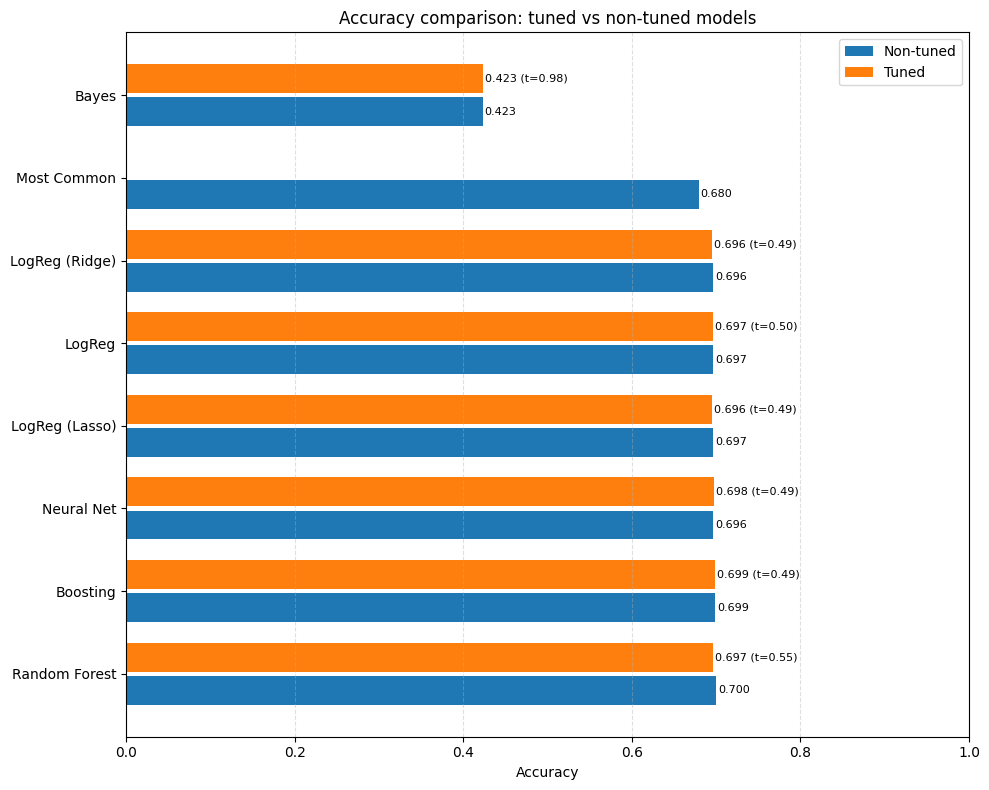

In [222]:
#Let us evaluate our models with the accuracy
#Accuracy measures: (TP + TN)/(TP + TN + FP + FN)

models = {
    "Most Common": (
        accuracy_score(y_test, y_pred_test_mc),
        None,
        None
    ),
    "Bayes": (
        accuracy_score(y_test, y_pred_test_bayes),
        accuracy_score(y_test, y_pred_test_bayes_tunedacc),
        best_t_Bayes_acc
    ),
    "LogReg": (
        accuracy_score(y_test, y_pred_test_lrc),
        accuracy_score(y_test, y_pred_lrcacc_test_best_thresh),
        best_threshold_lrc_acc
    ),
    "LogReg (Lasso)": (
        accuracy_score(y_test, y_pred_test_lrc_lasso),
        accuracy_score(y_test, y_pred_lrcacc_lasso_test_best_thresh),
        best_threshold_lrc_lasso_acc
    ),
    "LogReg (Ridge)": (
        accuracy_score(y_test, y_pred_test_lrc_ridge),
        accuracy_score(y_test, y_pred_lrcacc_ridge_test_best_thresh),
        best_threshold_lrc_ridge_acc
    ),
    "Neural Net": (
        accuracy_score(y_test, y_pred_test_neuron),
        accuracy_score(y_test, y_pred_test_neuronacc_hyp),
        neuron_tuned.best_threshold_
    ),
    "Random Forest": (
        accuracy_score(y_test, y_pred_test_rf),
        accuracy_score(y_test, y_pred_test_tunedacc_rf),
        search.best_params_["threshold"]
    ),
    "Boosting": (
        accuracy_score(y_test, y_pred_test_boosting),
        accuracy_score(y_test, y_pred_test_boostingacc_hyp),
        boosting_tuned.best_threshold_
    )
}

rows = []
for name, (acc_base, acc_tuned, t) in models.items():
    max_acc = max(a for a in [acc_base, acc_tuned] if a is not None)
    rows.append([name, acc_base, acc_tuned, t, max_acc])

df_acc = pd.DataFrame(rows, columns=["Model", "Acc_base", "Acc_tuned", "Threshold", "MaxAcc"])


df_acc = df_acc.sort_values("MaxAcc", ascending=False).reset_index(drop=True)


plt.figure(figsize=(10, 8))

y = np.arange(len(df_acc))

plt.barh(y - 0.2, df_acc["Acc_base"], height=0.35, label="Non-tuned")
plt.barh(y + 0.2, df_acc["Acc_tuned"], height=0.35, label="Tuned")


for i, row in enumerate(df_acc.itertuples()):
    
    plt.text(row.Acc_base + 0.002, i - 0.2, f"{row.Acc_base:.3f}",
             va="center", fontsize=8)
    
    if row.Acc_tuned is not None:
        if row.Threshold is not None:
            txt = f"{row.Acc_tuned:.3f} (t={row.Threshold:.2f})"
        else:
            txt = f"{row.Acc_tuned:.3f}"
        plt.text(row.Acc_tuned + 0.002, i + 0.2, txt,
                 va="center", fontsize=8)

plt.yticks(y, df_acc["Model"])
plt.xlabel("Accuracy")
plt.title("Accuracy comparison: tuned vs non-tuned models")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(0, 1)   
plt.tight_layout()
plt.show()



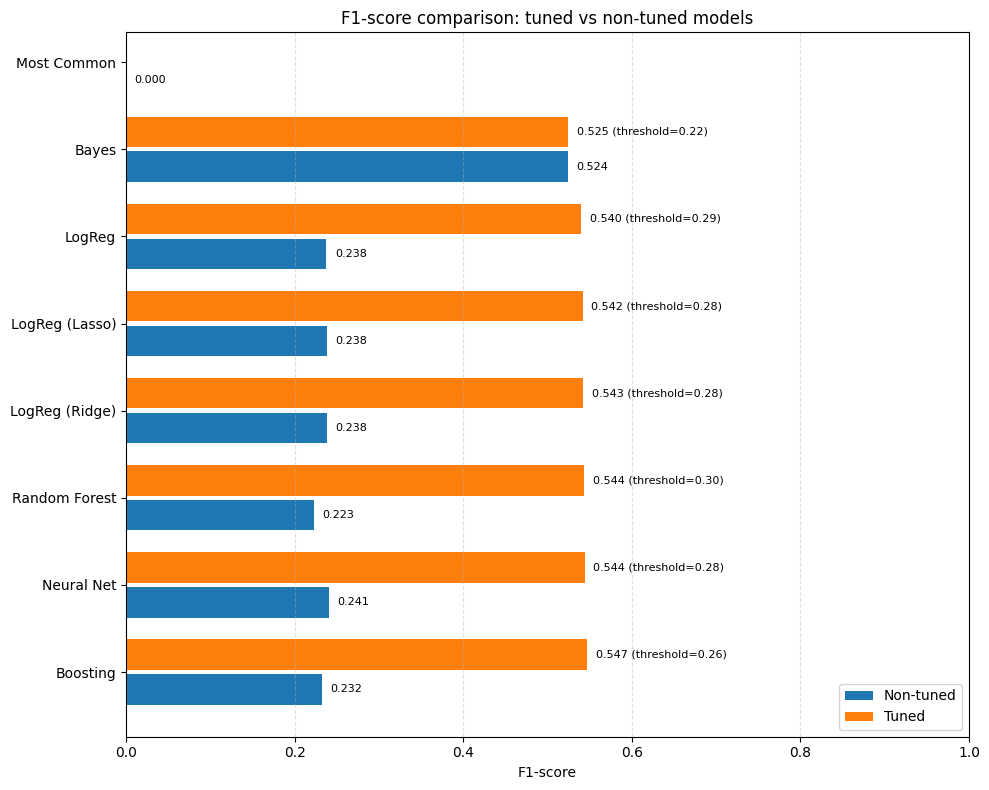

In [223]:
#Let us plot it
#F1-score measures: (2 · (Precision · Recall) / (Precision + Recall)) --> goal is to find an equilibrium between Precision and Recall

models = {
    "Most Common": (
        f1_score(y_test, y_pred_test_mc),
        None,
        None
    ),
    "Bayes": (
        f1_score(y_test, y_pred_test_bayes),
        f1_score(y_test, y_pred_test_bayes_tunedf1),
        best_t_Bayes_f1
    ),
    "LogReg": (
        f1_score(y_test, y_pred_test_lrc),
        f1_score(y_test, y_pred_lrcf1_test_best_thresh),
        best_threshold_lrc_f1
    ),
    "LogReg (Lasso)": (
        f1_score(y_test, y_pred_test_lrc_lasso),
        f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh),
        best_threshold_lrc_lasso_f1
    ),
    "LogReg (Ridge)": (
        f1_score(y_test, y_pred_test_lrc_ridge),
        f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh),
        best_threshold_lrc_ridge_f1
    ),
    "Neural Net": (
        f1_score(y_test, y_pred_test_neuron),
        f1_score(y_test, y_pred_test_neuronf1_hyp),
        neuron_tuned_f1.best_threshold_
    ),
    "Random Forest": (
        f1_score(y_test, y_pred_test_rf),
        f1_score(y_test, y_pred_test_tunedf1_rf),
        searchf1.best_params_["threshold"]
    ),
    "Boosting": (
        f1_score(y_test, y_pred_test_boosting),
        f1_score(y_test, y_pred_test_boostingf1_hyp),
        boosting_tuned_f1.best_threshold_
    )
}


rows = []
for name, (f1_base, f1_tuned, t) in models.items():
    max_f1 = max(f1 for f1 in [f1_base, f1_tuned] if f1 is not None)
    rows.append([name, f1_base, f1_tuned, t, max_f1])

df = pd.DataFrame(rows, columns=["Model", "F1_base", "F1_tuned", "Threshold", "MaxF1"])
df = df.sort_values("MaxF1", ascending=False)



plt.figure(figsize=(10, 8))

y = np.arange(len(df))

plt.barh(y - 0.2, df["F1_base"], height=0.35, label="Non-tuned")
plt.barh(y + 0.2, df["F1_tuned"], height=0.35, label="Tuned")


for i, row in df.iterrows():
    if row["F1_tuned"] is not None:
        plt.text(row["F1_tuned"] + 0.01, y[df.index.get_loc(i)] + 0.2, 
                 f"{row['F1_tuned']:.3f} (threshold={row['Threshold']:.2f})", 
                 va="center", fontsize=8)
    plt.text(row["F1_base"] + 0.01, y[df.index.get_loc(i)] - 0.2, 
             f"{row['F1_base']:.3f}", 
             va="center", fontsize=8)

plt.yticks(y, df["Model"])
plt.xlabel("F1-score")
plt.title("F1-score comparison: tuned vs non-tuned models")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [224]:

FeatureImportanceRF = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(FeatureImportanceRF.head(10).reset_index().drop(columns=["index"]))

,feature,importance
0,is_ltsourcing,0.217318
1,csc commercial gestures,0.064702
2,sales_band_0_500,0.054054
3,product_subcategory_Apparel (Clothing),0.051328
4,quantity_0.0,0.038282
5,product_subcategory_Footwear,0.033805
6,is exchange,0.032479
7,gift message flag,0.030451
8,guest,0.028132
9,sales type_ON BEHALF,0.026983
